In [1]:
# CORRECT - just use the module name
from gjepa.protein.data import load_scop, load_megascale_structures, load_megascale_ddg

# SCOP — loads ~4MB
scop = load_scop(limit=5)  # just first 5 proteins
g = scop[0]
print(f"Protein has {g.num_nodes} residues")
print(f"Sequence: {g.seq[:20]}...")
print(f"Node features shape: {g.x.shape}")
print(f"Edge index shape: {g.edge_index.shape}")
print(f"Edge attr shape: {g.edge_attr.shape}")
print(f"3D coords shape: {g.pos.shape}")

# MegaScale — loads ~60MB
structures = load_megascale_structures()
df = load_megascale_ddg()
print(df[['WT_name','mut_type','ddG','split']].head(10))
print(df['ddG'].describe())

ModuleNotFoundError: No module named 'gjepa'

In [3]:
import sys
sys.path.insert(0, r"C:\Users\fidan\sciml26_gjepa")

from gjepa.protein.data import load_scop, load_megascale_structures, load_megascale_ddg

scop       = load_scop(limit=5)
structures = load_megascale_structures()
df         = load_megascale_ddg()

c:\Users\fidan\sciml26_gjepa\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


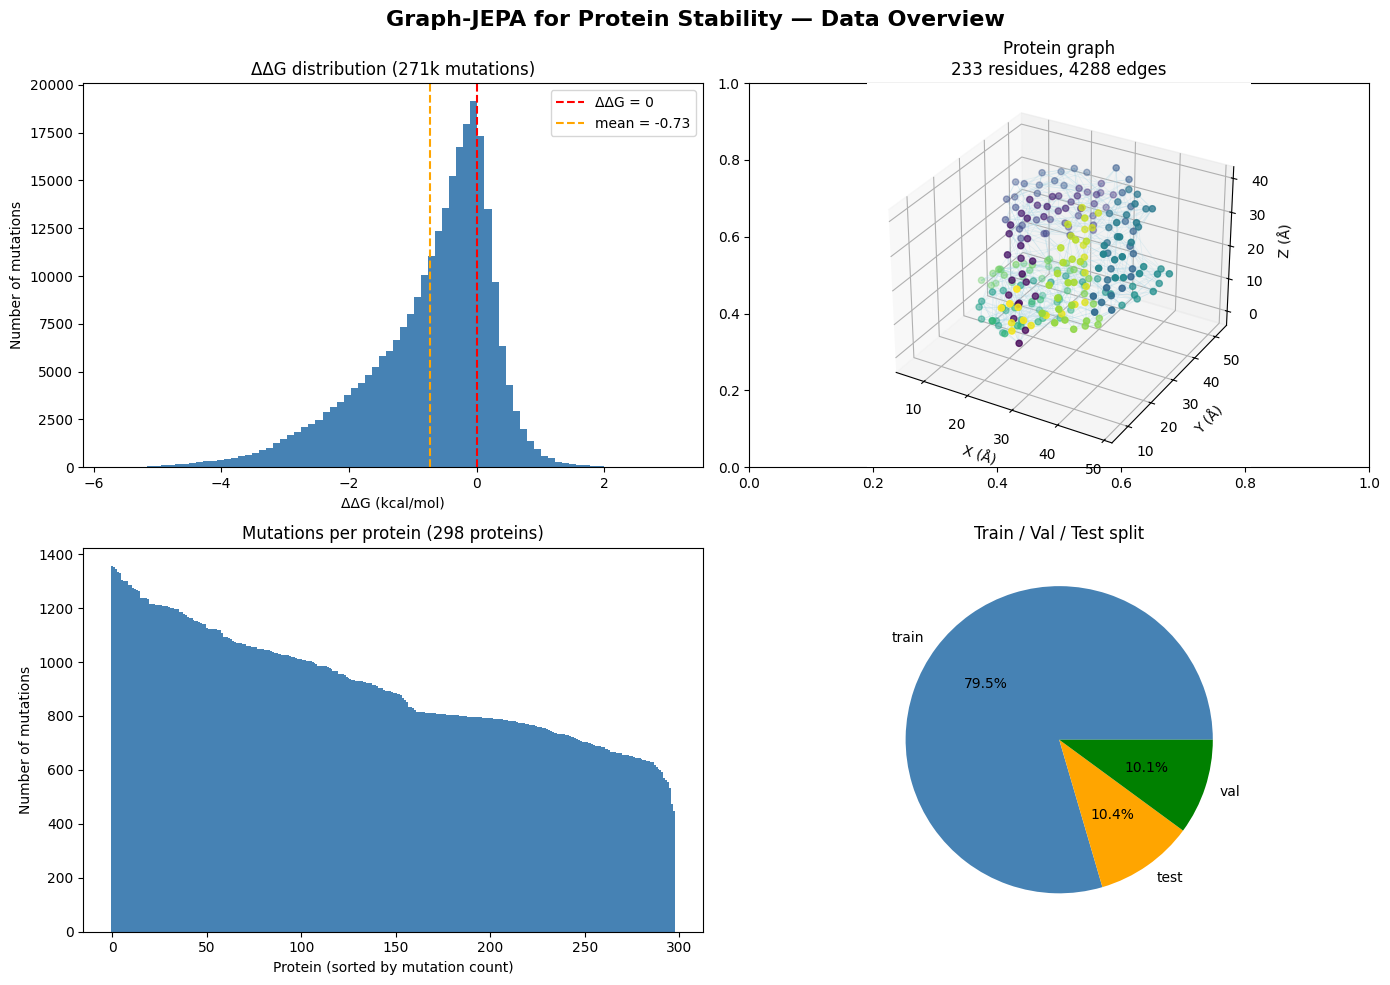

Saved as data_overview.png


In [7]:
# vizualization of data

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Graph-JEPA for Protein Stability — Data Overview', fontsize=16, fontweight='bold')

# 1. ΔΔG distribution
ax1 = axes[0, 0]
df_plot = df[df['ddG'].between(-6, 4)]
ax1.hist(df_plot['ddG'], bins=80, color='steelblue', edgecolor='none')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='ΔΔG = 0')
ax1.axvline(x=df['ddG'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f'mean = {df["ddG"].mean():.2f}')
ax1.set_xlabel('ΔΔG (kcal/mol)')
ax1.set_ylabel('Number of mutations')
ax1.set_title('ΔΔG distribution (271k mutations)')
ax1.legend()

# 2. Protein graph 3D
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
g = scop[0]
pos = g.pos.numpy()
edge_index = g.edge_index.numpy()
for i in range(0, edge_index.shape[1], 4):
    src, dst = edge_index[0, i], edge_index[1, i]
    ax2.plot([pos[src,0], pos[dst,0]],
             [pos[src,1], pos[dst,1]],
             [pos[src,2], pos[dst,2]],
             color='lightblue', alpha=0.3, linewidth=0.5)
ax2.scatter(pos[:,0], pos[:,1], pos[:,2],
            c=range(len(pos)), cmap='viridis', s=20, zorder=5)
ax2.set_title(f'Protein graph\n{g.num_nodes} residues, {edge_index.shape[1]} edges')
ax2.set_xlabel('X (Å)')
ax2.set_ylabel('Y (Å)')
ax2.set_zlabel('Z (Å)')

# 3. Mutations per protein
ax3 = axes[1, 0]
mutations_per_protein = df.groupby('WT_name').size().sort_values(ascending=False)
ax3.bar(range(len(mutations_per_protein)), mutations_per_protein.values, color='steelblue', width=1.0)
ax3.set_xlabel('Protein (sorted by mutation count)')
ax3.set_ylabel('Number of mutations')
ax3.set_title(f'Mutations per protein ({len(mutations_per_protein)} proteins)')

# 4. Train/val/test split
ax4 = axes[1, 1]
split_counts = df['split'].value_counts()
ax4.pie(split_counts.values,
        labels=split_counts.index,
        autopct='%1.1f%%',
        colors=['steelblue', 'orange', 'green'])
ax4.set_title('Train / Val / Test split')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as data_overview.png")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})

# ── 1. ΔΔG Distribution ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
df_plot = df[df['ddG'].between(-6, 4)]
n, bins, patches = ax.hist(df_plot['ddG'], bins=100, edgecolor='none', linewidth=0)

for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor('#c0392b' if left < 0 else '#27ae60')
    patch.set_alpha(0.85)

ax.axvline(0, color='#2c3e50', linewidth=1.2, linestyle='--', label='ΔΔG = 0')
ax.axvline(df['ddG'].mean(), color='#e67e22', linewidth=1.2, linestyle=':', label=f'mean = {df["ddG"].mean():.2f}')
ax.set_xlabel('ΔΔG  (kcal / mol)', fontsize=12, labelpad=8)
ax.set_ylabel('Mutation count', fontsize=12, labelpad=8)
ax.set_title('Most mutations destabilize proteins', fontsize=14, fontweight='bold', pad=14)
ax.annotate('75% of mutations\nhave ΔΔG < 0', xy=(-1.5, ax.get_ylim()[1]*0.7),
            fontsize=10, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            xytext=(-4.5, ax.get_ylim()[1]*0.8))
ax.legend(frameon=False, fontsize=10)
fig.text(0.01, 0.01, 'Source: MegaScale dataset (Tsuboyama et al., Nature 2023)',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig1_ddg_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig1_ddg_distribution.png")


# ── 2. Protein graph 3D ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#f0f4f8')

g = scop[0]
pos = g.pos.numpy()
ei  = g.edge_index.numpy()

# edges — draw every 3rd to keep it readable
for i in range(0, ei.shape[1], 3):
    s, d = ei[0, i], ei[1, i]
    ax.plot([pos[s,0], pos[d,0]],
            [pos[s,1], pos[d,1]],
            [pos[s,2], pos[d,2]],
            color='#95afc0', alpha=0.25, linewidth=0.6)

# nodes colored by sequence position
sc = ax.scatter(pos[:,0], pos[:,1], pos[:,2],
                c=np.arange(len(pos)), cmap='plasma',
                s=18, zorder=5, depthshade=True, alpha=0.9)
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Sequence position', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title(f'Protein residue graph\n{g.num_nodes} residues · {ei.shape[1]} edges · ~{ei.shape[1]//g.num_nodes} contacts/residue',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('X (Å)', fontsize=9, labelpad=4)
ax.set_ylabel('Y (Å)', fontsize=9, labelpad=4)
ax.set_zlabel('Z (Å)', fontsize=9, labelpad=4)
ax.tick_params(labelsize=7)
ax.view_init(elev=20, azim=45)
fig.text(0.01, 0.01, f'Sequence: {g.seq[:30]}...', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig2_protein_graph.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig2_protein_graph.png")


# ── 3. Mutations per protein ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
mpp = df.groupby('WT_name').size().sort_values(ascending=False)
x   = np.arange(len(mpp))

ax.fill_between(x, mpp.values, alpha=0.3, color='#2980b9')
ax.plot(x, mpp.values, color='#2980b9', linewidth=1.2)
ax.axhline(mpp.mean(), color='#e67e22', linewidth=1, linestyle='--',
           label=f'mean = {mpp.mean():.0f}')

ax.set_xlabel('Proteins (sorted by mutation count)', fontsize=12, labelpad=8)
ax.set_ylabel('Mutations measured', fontsize=12, labelpad=8)
ax.set_title('Mutation coverage varies widely across proteins', fontsize=14, fontweight='bold', pad=14)
ax.legend(frameon=False, fontsize=10)
ax.annotate(f'max = {mpp.max():,}', xy=(0, mpp.max()),
            xytext=(40, mpp.max()*0.9),
            fontsize=9, color='#2c3e50',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d'))
fig.text(0.01, 0.01, f'{len(mpp)} proteins  ·  {len(df):,} total mutations',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig3_mutations_per_protein.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig3_mutations_per_protein.png")


# ── 4. Benchmark comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

models  = ['Random\nbaseline', 'ThermoMPNN\n(no pretraining)', 'ThermoMPNN\n(pretrained)', 'Our model\n(target)']
scores  = [0.0, 0.642, 0.725, None]
colors  = ['#bdc3c7', '#e67e22', '#27ae60', '#95afc0']
hatches = ['', '', '', '//']

for i, (m, s, c, h) in enumerate(zip(models, scores, colors, hatches)):
    val = s if s is not None else 0.75
    bar = ax.bar(i, val, color=c, hatch=h, edgecolor='white',
                 linewidth=1.2, alpha=0.9, width=0.55)
    if s is not None:
        ax.text(i, val + 0.01, f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#2c3e50')
    else:
        ax.text(i, val + 0.01, '?', ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='#7f8c8d')

ax.axhline(0.725, color='#27ae60', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Spearman ρ', fontsize=12, labelpad=8)
ax.set_ylim(0, 0.9)
ax.set_title('Benchmark: Spearman correlation on MegaScale test set', fontsize=14, fontweight='bold', pad=14)
ax.annotate('our goal', xy=(3, 0.725), xytext=(2.3, 0.80),
            fontsize=9, color='#7f8c8d',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d'))
fig.text(0.01, 0.01, 'Reference: Dieckhaus et al., PNAS 2024', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig4_benchmark.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig4_benchmark.png")


# ── 5. ΔΔG by split (boxplot) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
splits  = ['train', 'val', 'test']
colors  = ['#3498db', '#e67e22', '#27ae60']
data    = [df[df['split'] == s]['ddG'].sample(min(50000, len(df[df['split']==s])), random_state=0).values
           for s in splits]

bp = ax.boxplot(data, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=1, alpha=0.2))

for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax.set_xticklabels([f'{s}\n(n={len(df[df["split"]==s]):,})' for s in splits], fontsize=11)
ax.set_ylabel('ΔΔG  (kcal / mol)', fontsize=12, labelpad=8)
ax.set_title('ΔΔG distribution is consistent across splits', fontsize=14, fontweight='bold', pad=14)
ax.axhline(0, color='#c0392b', linewidth=0.8, linestyle='--', alpha=0.6, label='ΔΔG = 0')
ax.legend(frameon=False, fontsize=10)
fig.text(0.01, 0.01, 'Splits are protein-disjoint — no protein appears in both train and test',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('fig5_ddg_by_split.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig5_ddg_by_split.png")

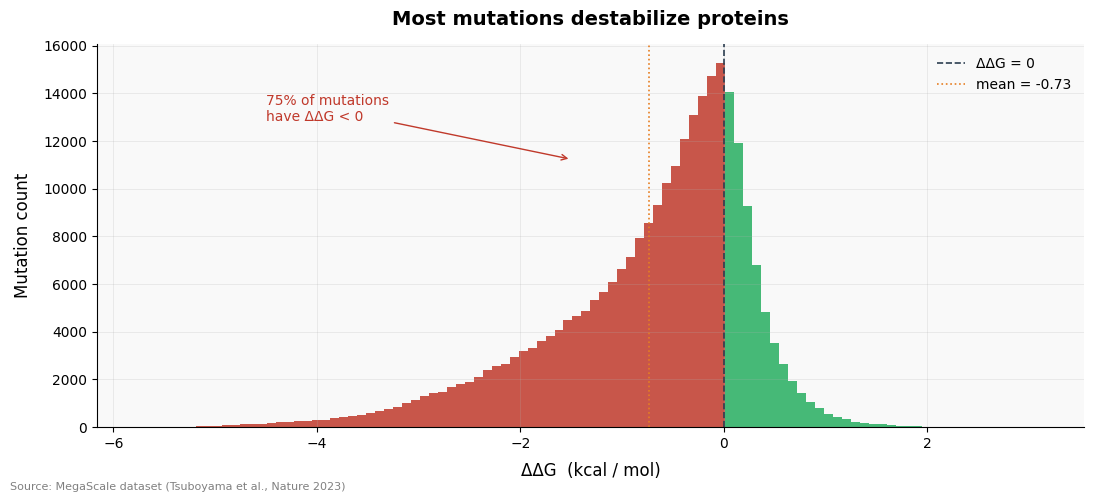

Saved: figures/fig1_ddg_distribution.png


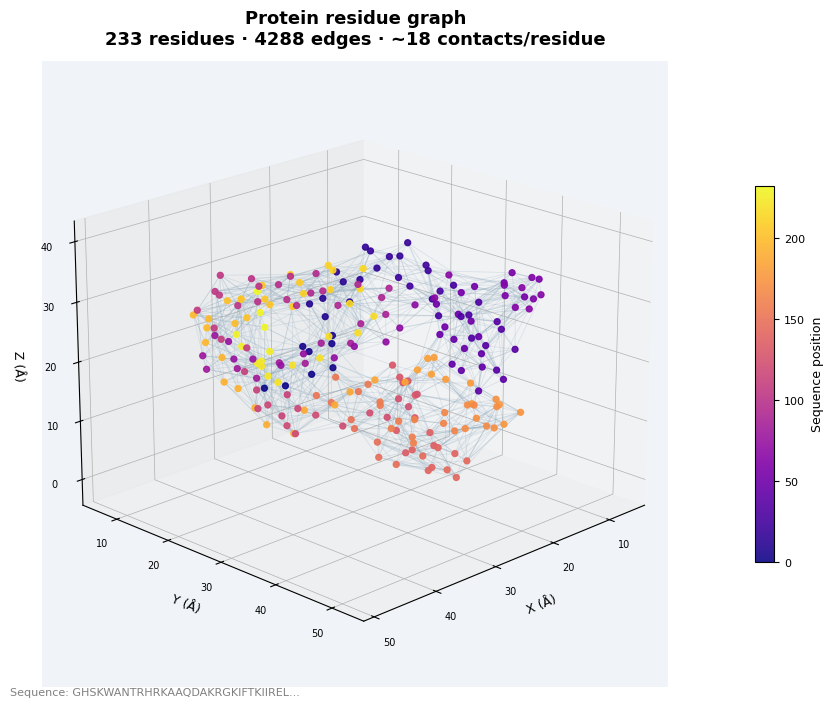

Saved: figures/fig2_protein_graph.png


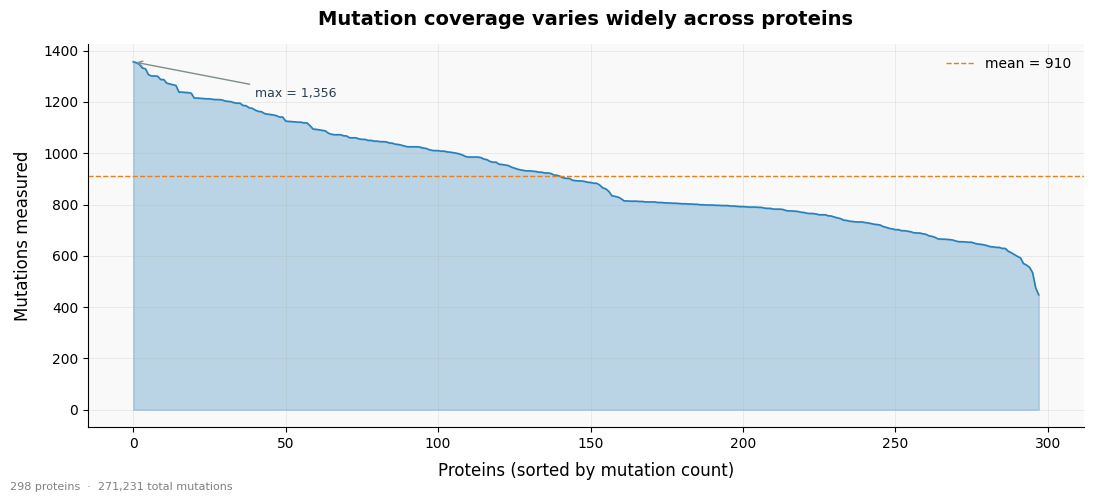

Saved: figures/fig3_mutations_per_protein.png


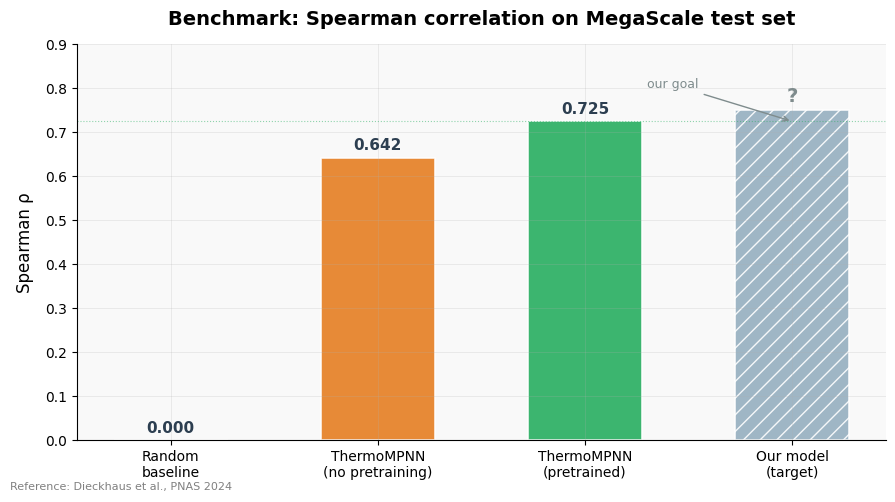

Saved: figures/fig4_benchmark.png


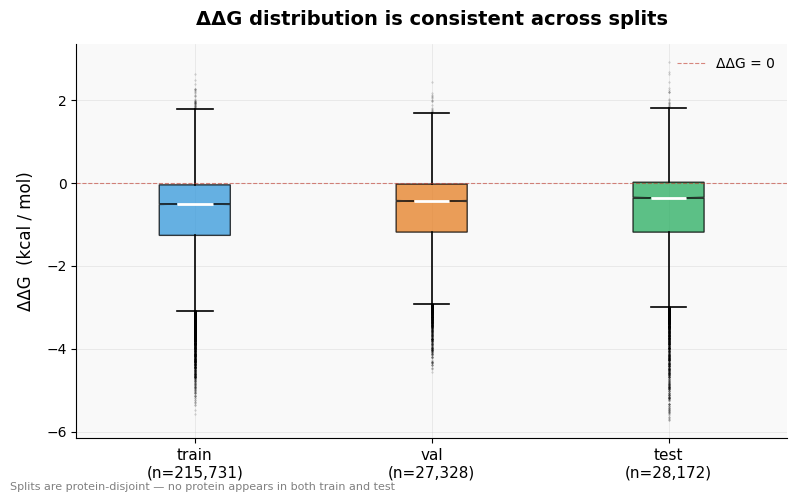

Saved: figures/fig5_ddg_by_split.png

All figures saved to: figures/


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})

# ── 1. ΔΔG Distribution ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
df_plot = df[df['ddG'].between(-6, 4)]
n, bins, patches = ax.hist(df_plot['ddG'], bins=100, edgecolor='none', linewidth=0)

for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor('#c0392b' if left < 0 else '#27ae60')
    patch.set_alpha(0.85)

ax.axvline(0, color='#2c3e50', linewidth=1.2, linestyle='--', label='ΔΔG = 0')
ax.axvline(df['ddG'].mean(), color='#e67e22', linewidth=1.2, linestyle=':', label=f'mean = {df["ddG"].mean():.2f}')
ax.set_xlabel('ΔΔG  (kcal / mol)', fontsize=12, labelpad=8)
ax.set_ylabel('Mutation count', fontsize=12, labelpad=8)
ax.set_title('Most mutations destabilize proteins', fontsize=14, fontweight='bold', pad=14)
ax.annotate('75% of mutations\nhave ΔΔG < 0', xy=(-1.5, ax.get_ylim()[1]*0.7),
            fontsize=10, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            xytext=(-4.5, ax.get_ylim()[1]*0.8))
ax.legend(frameon=False, fontsize=10)
fig.text(0.01, 0.01, 'Source: MegaScale dataset (Tsuboyama et al., Nature 2023)', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig1_ddg_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_ddg_distribution.png")


# ── 2. Protein graph 3D ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#f0f4f8')

g = scop[0]
pos = g.pos.numpy()
ei  = g.edge_index.numpy()

for i in range(0, ei.shape[1], 3):
    s, d = ei[0, i], ei[1, i]
    ax.plot([pos[s,0], pos[d,0]],
            [pos[s,1], pos[d,1]],
            [pos[s,2], pos[d,2]],
            color='#95afc0', alpha=0.25, linewidth=0.6)

sc = ax.scatter(pos[:,0], pos[:,1], pos[:,2],
                c=np.arange(len(pos)), cmap='plasma',
                s=18, zorder=5, depthshade=True, alpha=0.9)
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Sequence position', fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_title(f'Protein residue graph\n{g.num_nodes} residues · {ei.shape[1]} edges · ~{ei.shape[1]//g.num_nodes} contacts/residue',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('X (Å)', fontsize=9, labelpad=4)
ax.set_ylabel('Y (Å)', fontsize=9, labelpad=4)
ax.set_zlabel('Z (Å)', fontsize=9, labelpad=4)
ax.tick_params(labelsize=7)
ax.view_init(elev=20, azim=45)
fig.text(0.01, 0.01, f'Sequence: {g.seq[:30]}...', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig2_protein_graph.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_protein_graph.png")


# ── 3. Mutations per protein ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
mpp = df.groupby('WT_name').size().sort_values(ascending=False)
x   = np.arange(len(mpp))

ax.fill_between(x, mpp.values, alpha=0.3, color='#2980b9')
ax.plot(x, mpp.values, color='#2980b9', linewidth=1.2)
ax.axhline(mpp.mean(), color='#e67e22', linewidth=1, linestyle='--',
           label=f'mean = {mpp.mean():.0f}')
ax.set_xlabel('Proteins (sorted by mutation count)', fontsize=12, labelpad=8)
ax.set_ylabel('Mutations measured', fontsize=12, labelpad=8)
ax.set_title('Mutation coverage varies widely across proteins', fontsize=14, fontweight='bold', pad=14)
ax.legend(frameon=False, fontsize=10)
ax.annotate(f'max = {mpp.max():,}', xy=(0, mpp.max()),
            xytext=(40, mpp.max()*0.9),
            fontsize=9, color='#2c3e50',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d'))
fig.text(0.01, 0.01, f'{len(mpp)} proteins  ·  {len(df):,} total mutations', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig3_mutations_per_protein.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_mutations_per_protein.png")


# ── 4. Benchmark comparison ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

models  = ['Random\nbaseline', 'ThermoMPNN\n(no pretraining)', 'ThermoMPNN\n(pretrained)', 'Our model\n(target)']
scores  = [0.0, 0.642, 0.725, None]
colors  = ['#bdc3c7', '#e67e22', '#27ae60', '#95afc0']
hatches = ['', '', '', '//']

for i, (m, s, c, h) in enumerate(zip(models, scores, colors, hatches)):
    val = s if s is not None else 0.75
    ax.bar(i, val, color=c, hatch=h, edgecolor='white',
           linewidth=1.2, alpha=0.9, width=0.55)
    if s is not None:
        ax.text(i, val + 0.01, f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#2c3e50')
    else:
        ax.text(i, val + 0.01, '?', ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='#7f8c8d')

ax.axhline(0.725, color='#27ae60', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Spearman ρ', fontsize=12, labelpad=8)
ax.set_ylim(0, 0.9)
ax.set_title('Benchmark: Spearman correlation on MegaScale test set', fontsize=14, fontweight='bold', pad=14)
ax.annotate('our goal', xy=(3, 0.725), xytext=(2.3, 0.80),
            fontsize=9, color='#7f8c8d',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d'))
fig.text(0.01, 0.01, 'Reference: Dieckhaus et al., PNAS 2024', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig4_benchmark.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig4_benchmark.png")


# ── 5. ΔΔG by split (boxplot) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
splits = ['train', 'val', 'test']
colors = ['#3498db', '#e67e22', '#27ae60']
data   = [df[df['split'] == s]['ddG'].sample(min(50000, len(df[df['split']==s])), random_state=0).values
          for s in splits]

bp = ax.boxplot(data, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=1, alpha=0.2))

for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax.set_xticklabels([f'{s}\n(n={len(df[df["split"]==s]):,})' for s in splits], fontsize=11)
ax.set_ylabel('ΔΔG  (kcal / mol)', fontsize=12, labelpad=8)
ax.set_title('ΔΔG distribution is consistent across splits', fontsize=14, fontweight='bold', pad=14)
ax.axhline(0, color='#c0392b', linewidth=0.8, linestyle='--', alpha=0.6, label='ΔΔG = 0')
ax.legend(frameon=False, fontsize=10)
fig.text(0.01, 0.01, 'Splits are protein-disjoint — no protein appears in both train and test',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig5_ddg_by_split.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig5_ddg_by_split.png")

print("\nAll figures saved to: figures/")

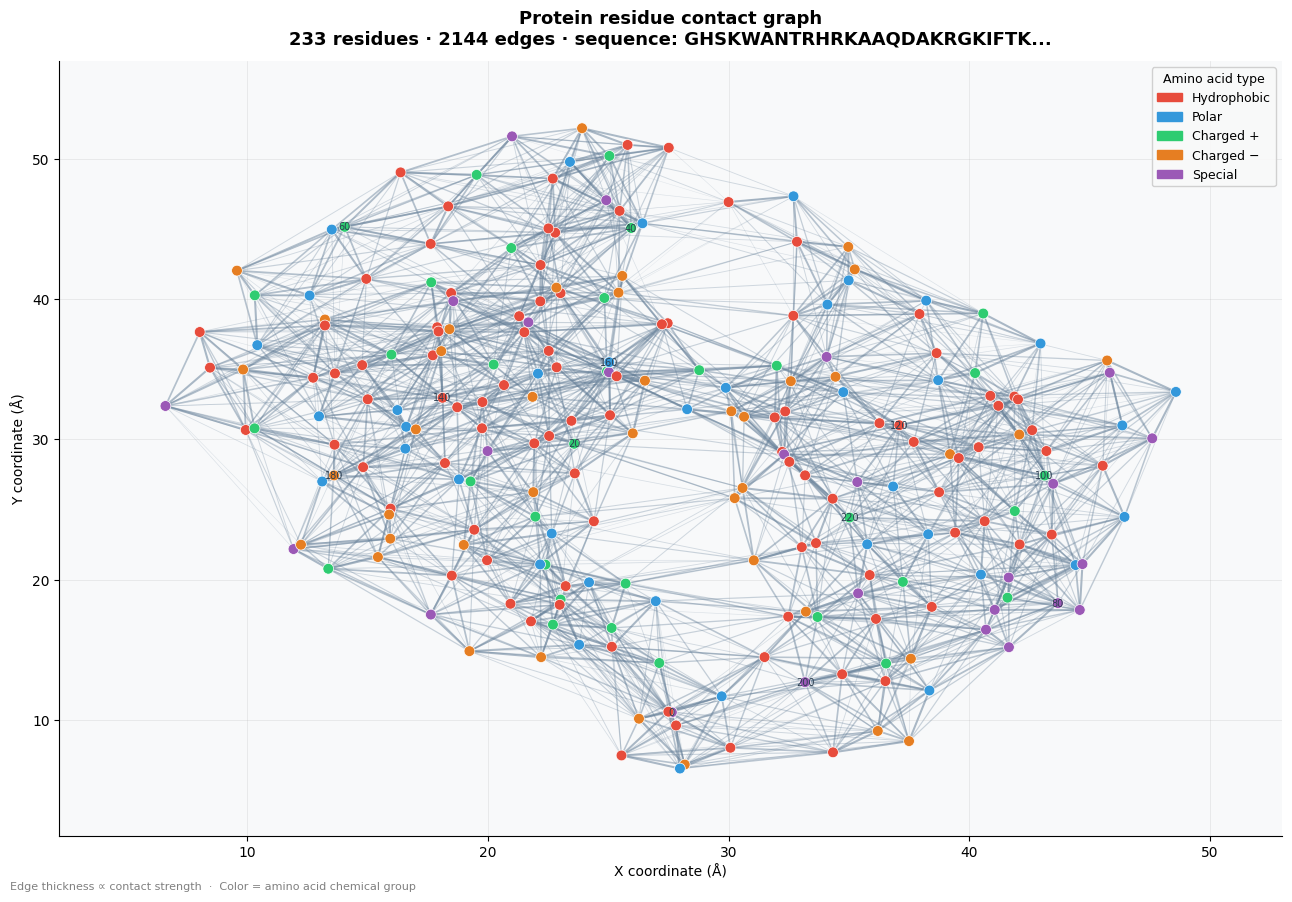

Saved: figures/fig6_protein_gnn_full.png


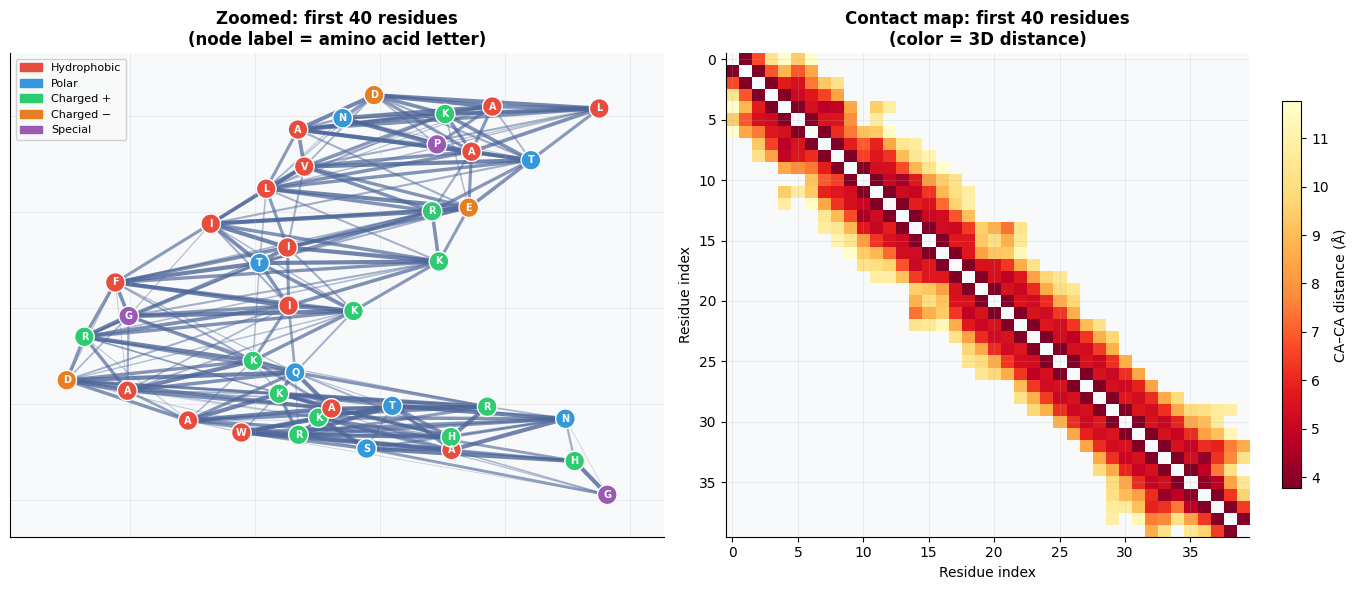

Saved: figures/fig7_protein_gnn_zoom.png


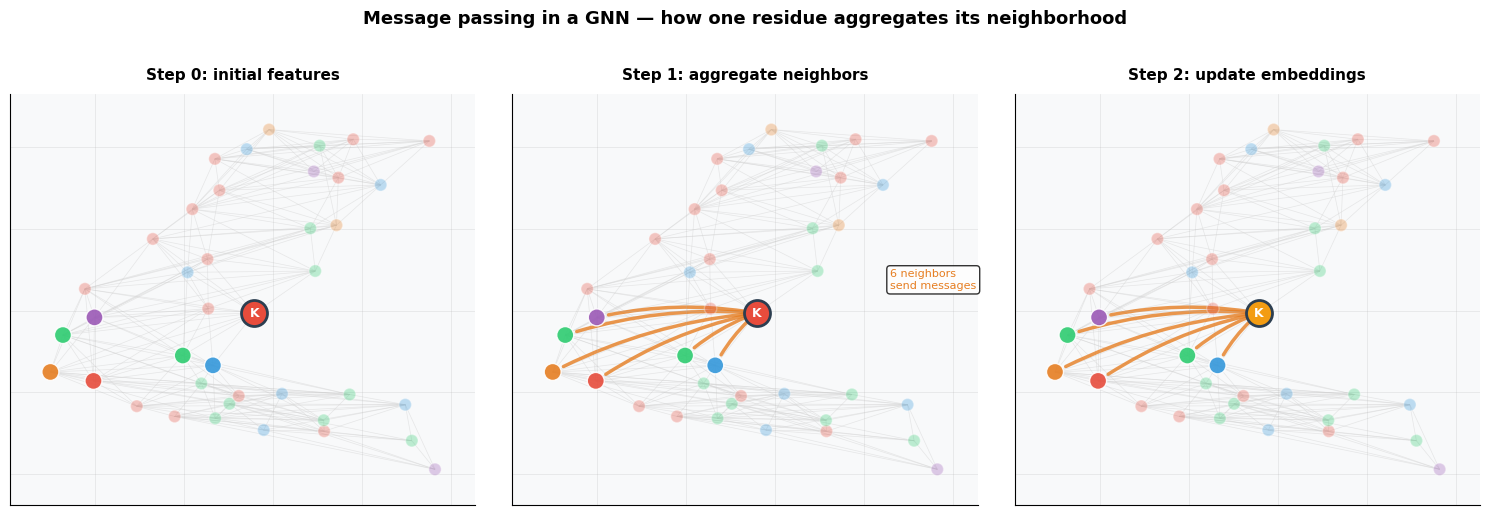

Saved: figures/fig8_message_passing.png

All GNN figures saved to: figures/


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

os.makedirs('figures', exist_ok=True)

# ── build networkx graph from real protein ───────────────────────────────────
g = scop[0]
pos2d    = g.pos.numpy()[:, :2]          # use X,Y coords as 2D layout
ei       = g.edge_index.numpy()
ea       = g.edge_attr.numpy()           # [distance, seq_sep]
seq      = g.seq
aa_ids   = g.x.numpy().flatten()

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_GROUPS = {
    'Hydrophobic': set('AVILMFYW'),
    'Polar':       set('STNQ'),
    'Charged +':   set('KRH'),
    'Charged −':   set('DE'),
    'Special':     set('CGP'),
}
GROUP_COLORS = {
    'Hydrophobic': '#e74c3c',
    'Polar':       '#3498db',
    'Charged +':   '#2ecc71',
    'Charged −':   '#e67e22',
    'Special':     '#9b59b6',
}

def aa_group(aa_char):
    for grp, chars in AA_GROUPS.items():
        if aa_char in chars:
            return grp
    return 'Special'

node_colors = []
for idx in aa_ids:
    if idx < len(AA):
        node_colors.append(GROUP_COLORS[aa_group(AA[idx])])
    else:
        node_colors.append('#95a5a6')

# ── build graph ──────────────────────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
for i in range(ei.shape[1]):
    s, d = int(ei[0, i]), int(ei[1, i])
    if s < d:
        G.add_edge(s, d, distance=float(ea[i, 0]), seq_sep=float(ea[i, 1]))

pos_dict = {i: pos2d[i] for i in range(g.num_nodes)}

# ── Figure 1: full protein graph ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9), facecolor='white')
ax.set_facecolor('#f8f9fa')

distances = [G[u][v]['distance'] for u, v in G.edges()]
max_d, min_d = max(distances), min(distances)
edge_alphas = [0.15 + 0.4 * (1 - (d - min_d) / (max_d - min_d + 1e-6)) for d in distances]
edge_widths = [0.3 + 1.2 * (1 - (d - min_d) / (max_d - min_d + 1e-6)) for d in distances]

nx.draw_networkx_edges(G, pos_dict, ax=ax,
                       width=edge_widths,
                       edge_color=[(0.4, 0.5, 0.6, a) for a in edge_alphas])
nx.draw_networkx_nodes(G, pos_dict, ax=ax,
                       node_color=node_colors,
                       node_size=60, linewidths=0.5,
                       edgecolors='white')

# sequence position labels for every 20th node
labels = {i: str(i) for i in range(0, g.num_nodes, 20)}
nx.draw_networkx_labels(G, pos_dict, labels=labels, ax=ax,
                        font_size=7, font_color='#2c3e50')

legend_handles = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLORS.items()]
ax.legend(handles=legend_handles, title='Amino acid type',
          loc='upper right', framealpha=0.9, fontsize=9, title_fontsize=9)

ax.set_title(f'Protein residue contact graph\n'
             f'{g.num_nodes} residues · {G.number_of_edges()} edges · '
             f'sequence: {seq[:25]}...',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('X coordinate (Å)', fontsize=10)
ax.set_ylabel('Y coordinate (Å)', fontsize=10)
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
fig.text(0.01, 0.005, 'Edge thickness ∝ contact strength  ·  Color = amino acid chemical group',
         fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig6_protein_gnn_full.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig6_protein_gnn_full.png")


# ── Figure 2: zoomed subgraph (first 40 residues) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# left — subgraph
sub_nodes = list(range(40))
SG = G.subgraph(sub_nodes)
sub_pos = {i: pos2d[i] for i in sub_nodes}
sub_colors = [node_colors[i] for i in sub_nodes]

ax = axes[0]
ax.set_facecolor('#f8f9fa')
sub_distances = [SG[u][v]['distance'] for u, v in SG.edges()]
if sub_distances:
    mx, mn = max(sub_distances), min(sub_distances)
    sub_widths = [0.5 + 2.5*(1-(d-mn)/(mx-mn+1e-6)) for d in sub_distances]
    sub_alphas = [0.3 + 0.5*(1-(d-mn)/(mx-mn+1e-6)) for d in sub_distances]
else:
    sub_widths, sub_alphas = [], []

nx.draw_networkx_edges(SG, sub_pos, ax=ax,
                       width=sub_widths,
                       edge_color=[(0.3, 0.4, 0.6, a) for a in sub_alphas])
nx.draw_networkx_nodes(SG, sub_pos, ax=ax,
                       node_color=sub_colors,
                       node_size=200, linewidths=1.0, edgecolors='white')
nx.draw_networkx_labels(SG, sub_pos,
                        labels={i: AA[aa_ids[i]] if aa_ids[i] < len(AA) else '?' for i in sub_nodes},
                        ax=ax, font_size=7, font_color='white', font_weight='bold')
ax.set_title('Zoomed: first 40 residues\n(node label = amino acid letter)', fontsize=12, fontweight='bold')
ax.set_facecolor('#f8f9fa')
ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9)

# right — edge distance heatmap
ax2 = axes[1]
n_show = 40
dist_matrix = np.full((n_show, n_show), np.nan)
for u, v, d in G.edges(data='distance'):
    if u < n_show and v < n_show:
        dist_matrix[u, v] = d
        dist_matrix[v, u] = d

im = ax2.imshow(dist_matrix, cmap='YlOrRd_r', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax2, label='CA–CA distance (Å)', shrink=0.8)
ax2.set_title('Contact map: first 40 residues\n(color = 3D distance)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residue index', fontsize=10)
ax2.set_ylabel('Residue index', fontsize=10)
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('figures/fig7_protein_gnn_zoom.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig7_protein_gnn_zoom.png")


# ── Figure 3: message passing illustration ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
titles = ['Step 0: initial features', 'Step 1: aggregate neighbors', 'Step 2: update embeddings']

center = 20
neighbors = list(G.neighbors(center))[:6]
highlight_nodes = [center] + neighbors
other_nodes = [n for n in sub_nodes if n not in highlight_nodes]

for step, ax in enumerate(axes):
    ax.set_facecolor('#f8f9fa')
    nx.draw_networkx_edges(SG, sub_pos, ax=ax, width=0.5,
                           edge_color='lightgray', alpha=0.5)
    if step >= 1:
        for nb in neighbors:
            if SG.has_edge(center, nb):
                nx.draw_networkx_edges(SG, sub_pos, ax=ax,
                                       edgelist=[(center, nb)],
                                       width=2.5, edge_color='#e67e22', alpha=0.8,
                                       arrows=True, arrowsize=15,
                                       connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_nodes(SG, sub_pos, nodelist=other_nodes, ax=ax,
                           node_color=[node_colors[i] for i in other_nodes],
                           node_size=80, alpha=0.3, edgecolors='white')
    nx.draw_networkx_nodes(SG, sub_pos, nodelist=neighbors, ax=ax,
                           node_color=[node_colors[i] for i in neighbors],
                           node_size=150, alpha=0.9, edgecolors='white')
    center_color = '#e74c3c' if step < 2 else '#f39c12'
    nx.draw_networkx_nodes(SG, sub_pos, nodelist=[center], ax=ax,
                           node_color=center_color,
                           node_size=350, edgecolors='#2c3e50', linewidths=2)
    nx.draw_networkx_labels(SG, sub_pos,
                            labels={center: AA[aa_ids[center]] if aa_ids[center] < len(AA) else '?'},
                            ax=ax, font_size=9, font_color='white', font_weight='bold')
    ax.set_title(titles[step], fontsize=11, fontweight='bold', pad=10)
    if step == 1:
        ax.annotate(f'{len(neighbors)} neighbors\nsend messages',
                    xy=sub_pos[center], xytext=(sub_pos[center][0]+3, sub_pos[center][1]+3),
                    fontsize=8, color='#e67e22',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Message passing in a GNN — how one residue aggregates its neighborhood',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig8_message_passing.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: figures/fig8_message_passing.png")

print("\nAll GNN figures saved to: figures/")


In [14]:
import subprocess
subprocess.run(['pip', 'install', 'plotly'], check=True)

CompletedProcess(args=['pip', 'install', 'plotly'], returncode=0)

In [12]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import networkx as nx
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

AA = "ACDEFGHIKLMNPQRSTVWY"
AA_GROUPS = {
    'Hydrophobic': set('AVILMFYW'),
    'Polar':       set('STNQ'),
    'Charged +':   set('KRH'),
    'Charged −':   set('DE'),
    'Special':     set('CGP'),
}
GROUP_COLORS = {
    'Hydrophobic': '#e74c3c',
    'Polar':       '#3498db',
    'Charged +':   '#2ecc71',
    'Charged −':   '#e67e22',
    'Special':     '#9b59b6',
}

def aa_group(c):
    for grp, chars in AA_GROUPS.items():
        if c in chars:
            return grp
    return 'Special'

g       = scop[0]
pos3d   = g.pos.numpy()
ei      = g.edge_index.numpy()
ea      = g.edge_attr.numpy()
seq     = g.seq
aa_ids  = g.x.numpy().flatten()

node_groups  = [aa_group(AA[i]) if i < len(AA) else 'Special' for i in aa_ids]
node_colors  = [GROUP_COLORS[grp] for grp in node_groups]
node_letters = [AA[i] if i < len(AA) else '?' for i in aa_ids]

# ── Figure 1: interactive 3D protein graph ───────────────────────────────────
edge_traces = []
distances = ea[:, 0]
max_d, min_d = distances.max(), distances.min()

for i in range(ei.shape[1]):
    s, d = int(ei[0, i]), int(ei[1, i])
    if s < d:
        dist = float(ea[i, 0])
        alpha = 0.08 + 0.3 * (1 - (dist - min_d) / (max_d - min_d + 1e-6))
        edge_traces.append(go.Scatter3d(
            x=[pos3d[s,0], pos3d[d,0], None],
            y=[pos3d[s,1], pos3d[d,1], None],
            z=[pos3d[s,2], pos3d[d,2], None],
            mode='lines',
            line=dict(color=f'rgba(100,140,180,{alpha:.2f})', width=1.5),
            hoverinfo='none',
            showlegend=False
        ))

node_traces = []
for grp, color in GROUP_COLORS.items():
    mask = [i for i, g_name in enumerate(node_groups) if g_name == grp]
    if not mask:
        continue
    node_traces.append(go.Scatter3d(
        x=pos3d[mask, 0],
        y=pos3d[mask, 1],
        z=pos3d[mask, 2],
        mode='markers',
        name=grp,
        marker=dict(size=5, color=color, opacity=0.9,
                    line=dict(color='white', width=0.5)),
        text=[f'Residue {i}<br>AA: {node_letters[i]}<br>Group: {node_groups[i]}<br>'
              f'Position: ({pos3d[i,0]:.1f}, {pos3d[i,1]:.1f}, {pos3d[i,2]:.1f})'
              for i in mask],
        hovertemplate='%{text}<extra></extra>'
    ))

fig1 = go.Figure(data=edge_traces + node_traces)
fig1.update_layout(
    title=dict(text=f'<b>Protein Residue Contact Graph</b><br>'
                    f'<sup>{g.num_nodes} residues · {ei.shape[1]//2} edges · '
                    f'hover over nodes for details</sup>',
               x=0.5, font=dict(size=16)),
    scene=dict(
        xaxis=dict(title='X (Å)', backgroundcolor='#f0f4f8', gridcolor='white'),
        yaxis=dict(title='Y (Å)', backgroundcolor='#f0f4f8', gridcolor='white'),
        zaxis=dict(title='Z (Å)', backgroundcolor='#f0f4f8', gridcolor='white'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
    ),
    legend=dict(title='Amino acid type', x=0.01, y=0.99,
                bgcolor='rgba(255,255,255,0.8)', borderwidth=1),
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=80, b=0),
    height=700,
)
fig1.write_html('figures/interactive_protein_graph_3d.html')
fig1.show()
print("Saved: figures/interactive_protein_graph_3d.html")


# ── Figure 2: interactive contact map ────────────────────────────────────────
n_show = 80
dist_matrix = np.full((n_show, n_show), np.nan)
for i in range(ei.shape[1]):
    s, d = int(ei[0, i]), int(ei[1, i])
    if s < n_show and d < n_show:
        dist_matrix[s, d] = float(ea[i, 0])
        dist_matrix[d, s] = float(ea[i, 0])

hover_text = [[
    f'Residue {r}: {node_letters[r]} ({node_groups[r]})<br>'
    f'Residue {c}: {node_letters[c]} ({node_groups[c]})<br>'
    f'Distance: {dist_matrix[r,c]:.2f} Å' if not np.isnan(dist_matrix[r,c])
    else f'No contact between {r} and {c}'
    for c in range(n_show)] for r in range(n_show)]

fig2 = go.Figure(go.Heatmap(
    z=dist_matrix,
    text=hover_text,
    hovertemplate='%{text}<extra></extra>',
    colorscale='YlOrRd_r',
    colorbar=dict(title='Distance (Å)'),
    zmin=0, zmax=20,
))
fig2.update_layout(
    title=dict(text=f'<b>Residue Contact Map</b><br>'
                    f'<sup>First {n_show} residues · darker = closer contact · hover for details</sup>',
               x=0.5, font=dict(size=16)),
    xaxis=dict(title='Residue index'),
    yaxis=dict(title='Residue index', autorange='reversed'),
    paper_bgcolor='white',
    height=650,
)
fig2.write_html('figures/interactive_contact_map.html')
fig2.show()
print("Saved: figures/interactive_contact_map.html")


# ── Figure 3: interactive ΔΔG explorer ───────────────────────────────────────
df_sample = df.sample(min(5000, len(df)), random_state=0).copy()
df_sample['abs_ddG'] = df_sample['ddG'].abs()
df_sample['effect'] = df_sample['ddG'].apply(
    lambda x: 'strongly destabilizing' if x < -2
    else 'destabilizing' if x < 0
    else 'neutral' if x < 0.5
    else 'stabilizing'
)
effect_colors = {
    'strongly destabilizing': '#c0392b',
    'destabilizing':          '#e67e22',
    'neutral':                '#95a5a6',
    'stabilizing':            '#27ae60',
}

fig3 = px.scatter(
    df_sample,
    x='ddG',
    y='abs_ddG',
    color='effect',
    color_discrete_map=effect_colors,
    hover_data=['WT_name', 'mut_type', 'ddG', 'split'],
    labels={'ddG': 'ΔΔG (kcal/mol)', 'abs_ddG': '|ΔΔG| magnitude'},
    title='<b>Mutation stability explorer</b><br><sup>5,000 random mutations · hover for details · click legend to filter</sup>',
    opacity=0.6,
    size='abs_ddG',
    size_max=12,
)
fig3.add_vline(x=0, line_dash='dash', line_color='#2c3e50', annotation_text='ΔΔG = 0')
fig3.add_vline(x=df['ddG'].mean(), line_dash='dot', line_color='#8e44ad',
               annotation_text=f'mean = {df["ddG"].mean():.2f}')
fig3.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='#f9f9f9',
    height=600,
    legend=dict(title='Effect', bgcolor='rgba(255,255,255,0.8)', borderwidth=1),
)
fig3.write_html('figures/interactive_ddg_explorer.html')
fig3.show()
print("Saved: figures/interactive_ddg_explorer.html")


# ── Figure 4: message passing animation ──────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
for i in range(ei.shape[1]):
    s, d = int(ei[0, i]), int(ei[1, i])
    if s < d:
        G.add_edge(s, d)

center    = 20
neighbors = list(G.neighbors(center))[:8]
pos2d     = g.pos.numpy()[:, :2]

frames = []
steps  = [
    ('Initial state', [], '#e74c3c'),
    ('Neighbors send messages', neighbors, '#e67e22'),
    ('Center aggregates', neighbors, '#f39c12'),
    ('Updated embedding', [], '#27ae60'),
]

for step_name, active_edges, center_col in steps:
    edge_x, edge_y, active_x, active_y = [], [], [], []
    sub = list(range(40))
    SG  = G.subgraph(sub)

    for u, v in SG.edges():
        edge_x += [pos2d[u,0], pos2d[v,0], None]
        edge_y += [pos2d[u,1], pos2d[v,1], None]

    for nb in active_edges:
        active_x += [pos2d[center,0], pos2d[nb,0], None]
        active_y += [pos2d[center,1], pos2d[nb,1], None]

    frames.append(go.Frame(
        data=[
            go.Scatter(x=edge_x, y=edge_y, mode='lines',
                       line=dict(color='lightgray', width=0.8), showlegend=False),
            go.Scatter(x=active_x, y=active_y, mode='lines',
                       line=dict(color='#e67e22', width=3), showlegend=False),
            go.Scatter(
                x=[pos2d[i,0] for i in sub if i != center],
                y=[pos2d[i,1] for i in sub if i != center],
                mode='markers',
                marker=dict(size=10,
                            color=[node_colors[i] for i in sub if i != center],
                            opacity=[0.9 if i in active_edges else 0.3 for i in sub if i != center]),
                text=[f'Residue {i}: {node_letters[i]}' for i in sub if i != center],
                hovertemplate='%{text}<extra></extra>',
                showlegend=False,
            ),
            go.Scatter(
                x=[pos2d[center,0]], y=[pos2d[center,1]],
                mode='markers+text',
                marker=dict(size=22, color=center_col,
                            line=dict(color='white', width=2)),
                text=[node_letters[center]],
                textposition='middle center',
                textfont=dict(color='white', size=10, family='Arial Black'),
                hovertemplate=f'Center residue {center}: {node_letters[center]}<extra></extra>',
                showlegend=False,
            ),
        ],
        name=step_name,
        layout=go.Layout(title_text=f'<b>Message Passing — {step_name}</b>')
    ))

fig4 = go.Figure(
    data=frames[0].data,
    frames=frames,
    layout=go.Layout(
        title=dict(text='<b>Message Passing — Initial state</b>', x=0.5, font=dict(size=15)),
        paper_bgcolor='white',
        plot_bgcolor='#f8f9fa',
        height=550,
        xaxis=dict(title='X (Å)', showgrid=False),
        yaxis=dict(title='Y (Å)', showgrid=False),
        updatemenus=[dict(
            type='buttons', showactive=False,
            y=1.15, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶  Play',
                     method='animate',
                     args=[None, dict(frame=dict(duration=1200, redraw=True),
                                      fromcurrent=True, mode='immediate')]),
                dict(label='⏸  Pause',
                     method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')]),
            ]
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name],
                        dict(mode='immediate', frame=dict(duration=0, redraw=True))],
                        label=f.name) for f in frames],
            x=0.05, y=0, len=0.9,
            currentvalue=dict(prefix='Step: ', font=dict(size=11)),
        )]
    )
)
fig4.write_html('figures/interactive_message_passing.html')
fig4.show()
print("Saved: figures/interactive_message_passing.html")

print("\nAll interactive figures saved to: figures/")
print("Open the .html files in your browser for full interactivity!")

Saved: figures/interactive_protein_graph_3d.html


Saved: figures/interactive_contact_map.html


Saved: figures/interactive_ddg_explorer.html


Saved: figures/interactive_message_passing.html

All interactive figures saved to: figures/
Open the .html files in your browser for full interactivity!


In [5]:
import subprocess
subprocess.run(['pip', 'install', 'plotly'], check=True)

CompletedProcess(args=['pip', 'install', 'plotly'], returncode=0)